# Chemistry graphicalizer demo

This notebook demonstrates the wave-1 chemistry workflow in `abstractgraph-graphicalizer`: SMILES to labeled NetworkX graphs, `.sdf` ingestion, schema inspection, and both drawing helpers.

In [1]:
from pathlib import Path
import runpy

BOOTSTRAP_CANDIDATES = (
    "notebooks/_bootstrap.py",
    "abstractgraph/notebooks/_bootstrap.py",
    "abstractgraph-ml/notebooks/_bootstrap.py",
    "abstractgraph-generative/notebooks/_bootstrap.py",
    "abstractgraph-graphicalizer/notebooks/_bootstrap.py",
)

_bootstrap_path = next(
    (
        candidate / relative
        for candidate in (Path.cwd(), *Path.cwd().parents)
        for relative in BOOTSTRAP_CANDIDATES
        if (candidate / relative).exists()
    ),
    None,
)
if _bootstrap_path is None:
    raise FileNotFoundError("Could not locate ecosystem notebooks/_bootstrap.py")

_bootstrap = runpy.run_path(str(_bootstrap_path))
repo_root = _bootstrap["repo_root"]
workspace_root = _bootstrap["workspace_root"]


In [2]:
import tempfile
from pathlib import Path

from abstractgraph_graphicalizer.chem import (
    CHEM_EDGE_SCHEMA,
    CHEM_NODE_SCHEMA,
    draw_graph,
    draw_molecule,
    sdf_to_graphs,
    smiles_to_graph,
)
from abstractgraph_graphicalizer.chem.molecules import Chem


In [3]:
CHEM_NODE_SCHEMA, CHEM_EDGE_SCHEMA

({'label': "Atomic symbol string, for example 'C' or 'O'.",
  'atomic_num': 'Atomic number.',
  'formal_charge': 'Formal charge as an integer.',
  'aromatic': 'Whether the atom is aromatic.'},
 {'label': "Bond type label string: 'single', 'double', 'triple', or 'aromatic'.",
  'bond_order': 'Numeric bond order as a float.',
  'bond_type': 'Original RDKit bond type string.',
  'aromatic': 'Whether the bond is aromatic.'})

In [4]:
ethanol_graph = smiles_to_graph("CCO")
ethanol_graph.nodes(data=True), ethanol_graph.edges(data=True), ethanol_graph.graph

(NodeDataView({0: {'label': 'C', 'atomic_num': 6, 'formal_charge': 0, 'aromatic': False}, 1: {'label': 'C', 'atomic_num': 6, 'formal_charge': 0, 'aromatic': False}, 2: {'label': 'O', 'atomic_num': 8, 'formal_charge': 0, 'aromatic': False}}),
 EdgeDataView([(0, 1, {'label': 'single', 'bond_order': 1.0, 'bond_type': 'SINGLE', 'aromatic': False}), (1, 2, {'label': 'single', 'bond_order': 1.0, 'bond_type': 'SINGLE', 'aromatic': False})]),
 {'source': 'smiles', 'input': 'CCO'})

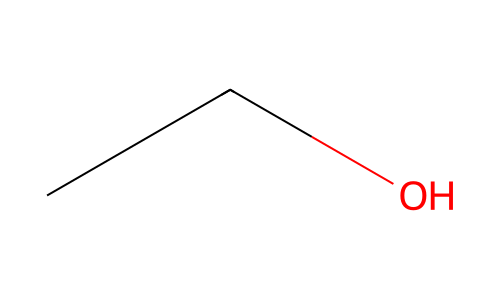

In [5]:
draw_molecule(ethanol_graph)

<Axes: >

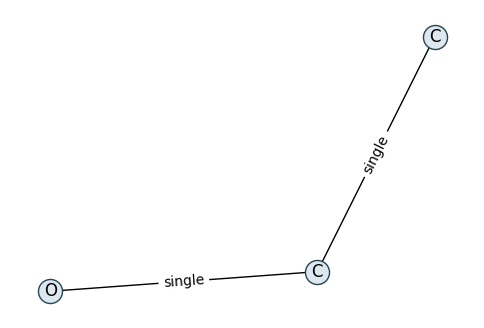

In [6]:
draw_graph(ethanol_graph)

In [7]:
tmpdir = Path(tempfile.mkdtemp())
sdf_path = tmpdir / "molecules.sdf"
writer = Chem.SDWriter(str(sdf_path))
writer.write(Chem.MolFromSmiles("CCO"))
writer.write(Chem.MolFromSmiles("C=C"))
writer.close()

sdf_graphs = list(sdf_to_graphs(sdf_path))
len(sdf_graphs), sdf_graphs[0].graph, sdf_graphs[1].edges(data=True)

(2,
 {'source': 'sdf', 'input': '/tmp/tmpy8i9n12k/molecules.sdf[0]'},
 EdgeDataView([(0, 1, {'label': 'double', 'bond_order': 2.0, 'bond_type': 'DOUBLE', 'aromatic': False})]))